# Armenian Calamari Test CER

Evaluate a Calamari checkpoint on the Armenian finetuning test split and report character error rate (CER).

Default paths:
- Checkpoint: `checkpoints/calamari/finetuned/on_armenian/lstm_3/final/best.pt`
- Test set: `data/processed/armenian/finetuning` (`gt_test.txt` + `image/`)


In [ ]:
import sys
from pathlib import Path

import torch
from IPython.display import display, Image as IPyImage


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current notebook working directory.")


REPO = find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.inference.calamari import _load_image
from src.models.calamari.checkpoint import load_calamari_checkpoint
from src.models.calamari.codec import CharacterCodec
# Latest cleaned-pretrain finetune (val-best, epoch 61)
CHECKPOINT = (
    REPO
    / "checkpoints"
    / "calamari"
    / "finetuned"
    / "on_armenian"
    / "lstm_3"
    / "final"
    / "best.pt"
)
EVAL_DIR = REPO / "data" / "processed" / "armenian" / "finetuning"
IMAGE_DIR = EVAL_DIR / "image"
GT_FILE = EVAL_DIR / "gt_test.txt"

ground_truth = {}
for line in GT_FILE.read_text(encoding="utf-8").splitlines():
    if not line:
        continue
    image_name, text = line.split("\t", 1)
    ground_truth[image_name] = text

test_images = sorted(IMAGE_DIR / name for name in ground_truth if (IMAGE_DIR / name).is_file())

assert CHECKPOINT.exists(), f"Missing checkpoint: {CHECKPOINT}"
assert EVAL_DIR.exists(), f"Missing evaluation directory: {EVAL_DIR}"
assert test_images, f"No test images found for {GT_FILE}"

print(f"Repo root:           {REPO}")
print(f"Checkpoint:          {CHECKPOINT}")
print(f"Test dir:            {EVAL_DIR}")
print(f"Test samples:        {len(test_images)}")


Repo root:           /home/ra48vol/greek-ocr
Checkpoint:          /home/ra48vol/greek-ocr/checkpoints/calamari/finetuned/on_armenian/lstm_2/calamari-finetuning-armenian--20260828T115331860332Z--local-fd13ba76/best.pt
Test dir:            /home/ra48vol/greek-ocr/data/processed/armenian/finetuning
Test samples:        120


In [ ]:
model, metadata = load_calamari_checkpoint(CHECKPOINT)
codec = CharacterCodec(metadata.charset)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()
print(f"Prediction device:   {device}")
print(f"Line height:         {metadata.line_height}")


def predict_image(image_path: Path) -> str:
    image = _load_image(image_path, metadata.line_height).to(device)
    lengths = torch.tensor([image.shape[1]], device=device)
    with torch.no_grad():
        output = model(image, lengths)
    return codec.decode_logits(output["logits"], output["out_len"])[0]


def levenshtein_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        curr = [i]
        for j, char_b in enumerate(b, start=1):
            cost = 0 if char_a == char_b else 1
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost))
        prev = curr
    return prev[-1]


def character_error_rate(reference: str, prediction: str) -> float:
    if not reference:
        return 0.0 if not prediction else 1.0
    return levenshtein_distance(reference, prediction) / len(reference)


Prediction device:   cuda
Line height:         48


Evaluating 30 random test samples.

----------------------------------------------------------------------------------------------------
Sample 01 | ms_p_172__0007__003


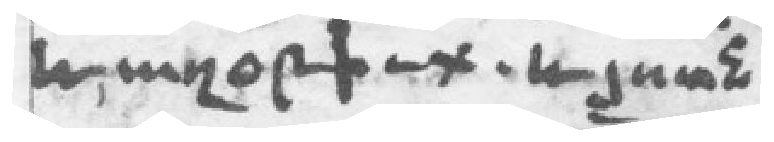

GT:   ևաղօթիւք․ ևյոտն
PRED: ևազօբիւք ևյուն
CER:  0.2667 (26.67%)
----------------------------------------------------------------------------------------------------
Sample 02 | ms_p_172__0007__004


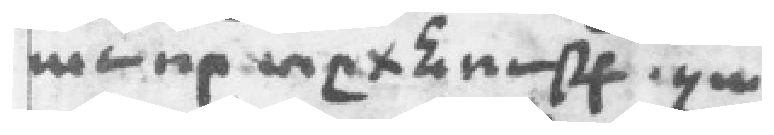

GT:   աւոր տըքնութբ․ զա
PRED: աւորաըքնութբ․ զա
CER:  0.1176 (11.76%)
----------------------------------------------------------------------------------------------------
Sample 03 | ms_p_172__0007__011


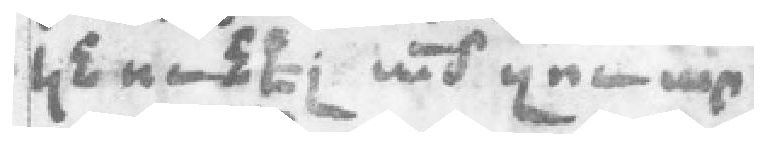

GT:   կնունել ամզուար
PRED: կնունել ամ զուար
CER:  0.0667 (6.67%)
----------------------------------------------------------------------------------------------------
Sample 04 | ms_p_172__0007__013


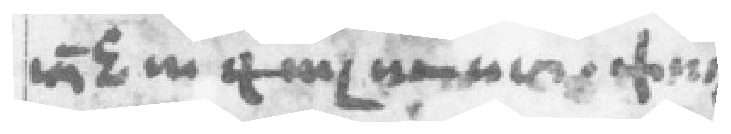

GT:   տնագալուստփող
PRED: տնագալաստ․ փոյ
CER:  0.3846 (38.46%)
----------------------------------------------------------------------------------------------------
Sample 05 | ms_p_172__0007__014


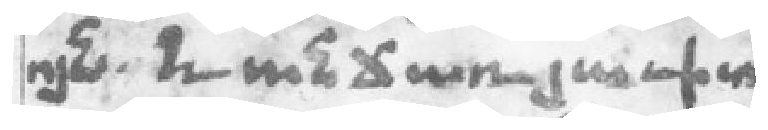

GT:   ոյն․ ևանճառյաւիտ
PRED: ոն․ ևանճառյաւիտ
CER:  0.0625 (6.25%)
----------------------------------------------------------------------------------------------------
Sample 06 | ms_p_172__0007__017


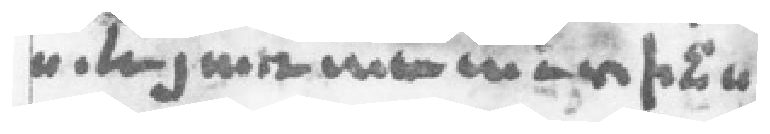

GT:   ս․ ևյառաւաւտինս
PRED: ս․ ևյառաւաւտինս
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 07 | ms_p_172__0007__025


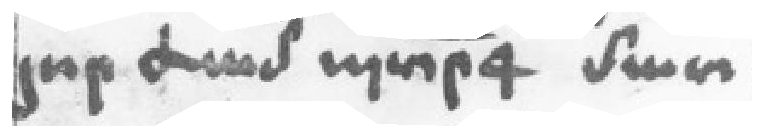

GT:   յորժամ պտրգ մատ
PRED: յորժամ պտրգ մատ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 08 | ms_p_172__0007__027


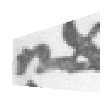

GT:   ռճ
PRED: ռճ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 09 | ms_p_172__0007__028


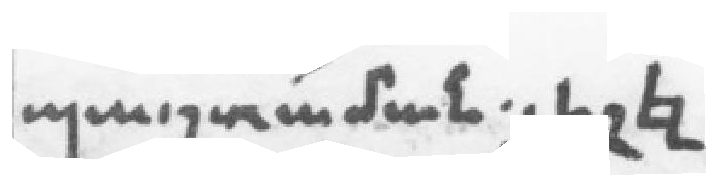

GT:   պաշտաման․ յիշել
PRED: պատումանա ւել
CER:  0.4667 (46.67%)
----------------------------------------------------------------------------------------------------
Sample 10 | ms_p_172__0007__029


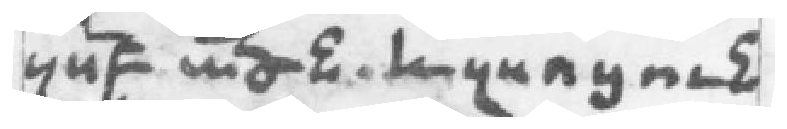

GT:   զսբ ածն․ ևզսոցուն
PRED: զսբածն․ ևզսոցուն
CER:  0.0588 (5.88%)
----------------------------------------------------------------------------------------------------
Sample 11 | ms_p_172__0007__031


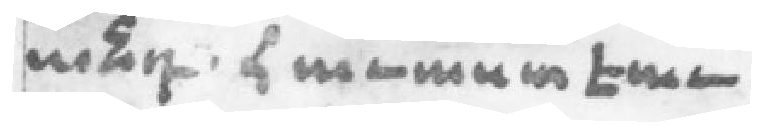

GT:   անդ․ հաւաստեաւ
PRED: անդ հաւաստեաւ
CER:  0.0714 (7.14%)
----------------------------------------------------------------------------------------------------
Sample 12 | ms_p_172__0007__035


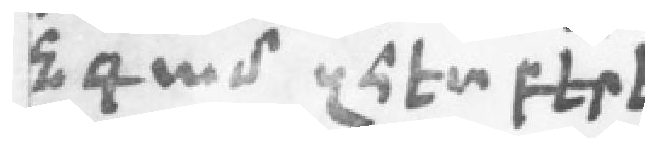

GT:   նգամ զհետբերել․
PRED: նգամ զհետբերի
CER:  0.2000 (20.00%)
----------------------------------------------------------------------------------------------------
Sample 13 | ms_p_172__0007__054


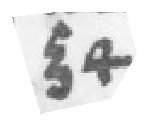

GT:   ձգ
PRED: կ
CER:  1.0000 (100.00%)
----------------------------------------------------------------------------------------------------
Sample 14 | ms_p_331_ff24r_34r__0012_29v__017


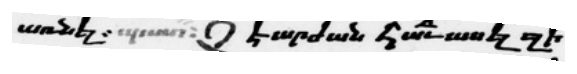

GT:   առնել։ պատ։ Չ էարժան հաւասել զի
PRED: առնել։ պատ։ ջ էարման հաւասել զի
CER:  0.0645 (6.45%)
----------------------------------------------------------------------------------------------------
Sample 15 | ms_p_331_ff24r_34r__0013_30r__029


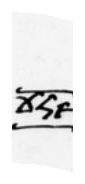

GT:   ճհբ
PRED: ճհբ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 16 | ms_ucla_ms__0010__000


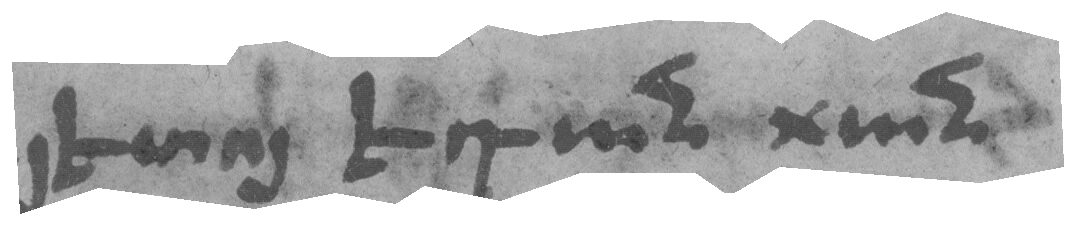

GT:   յետոյ եդան քան
PRED: թետց եդանքան
CER:  0.2857 (28.57%)
----------------------------------------------------------------------------------------------------
Sample 17 | ms_ucla_ms__0010__004


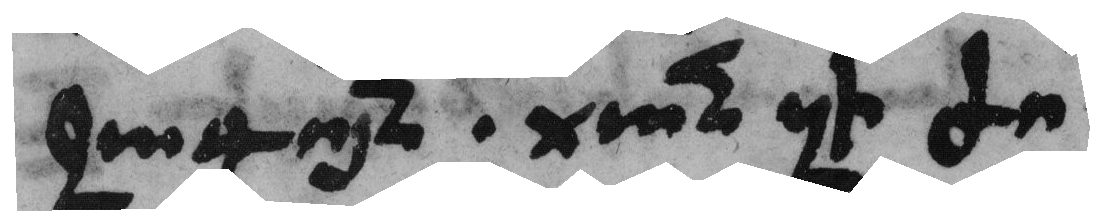

GT:   ջագոյն․ քան զի ժո
PRED: վաւոյն․ քան զի էր
CER:  0.2353 (23.53%)
----------------------------------------------------------------------------------------------------
Sample 18 | ms_ucla_ms__0010__006


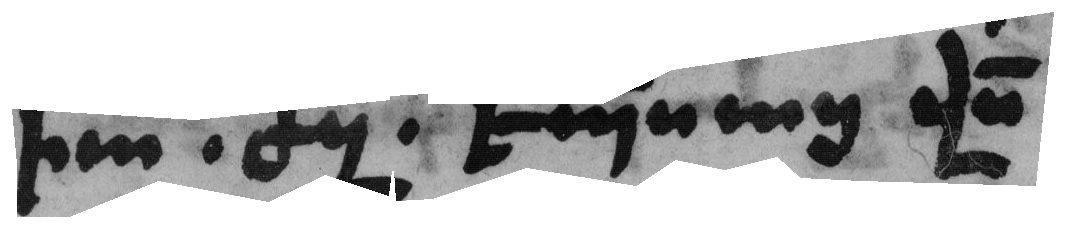

GT:   իա՛ ․ժզ․ եպսաց վս
PRED: իտ՛․եզ․եպսաց վս
CER:  0.2353 (23.53%)
----------------------------------------------------------------------------------------------------
Sample 19 | ms_ucla_ms__0010__010


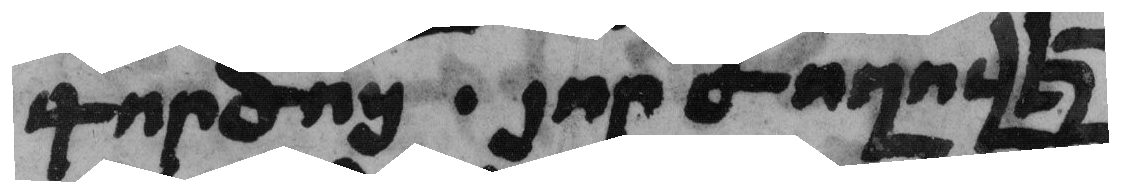

GT:   գործոց․ յորժողովել
PRED: գործոց․ յորժողովել
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 20 | ms_ucla_ms__0010__012


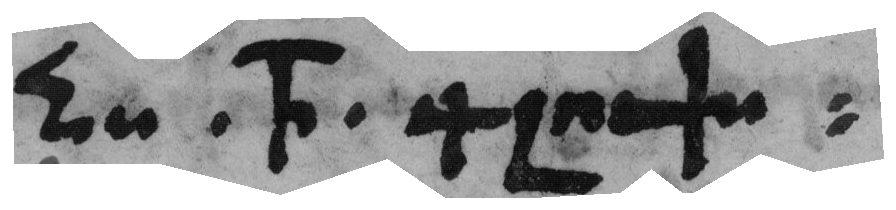

GT:   նս ․ի․ գլուխ։
PRED: նս ․ի․ գլուխ։
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 21 | ms_ucla_ms__0010__015


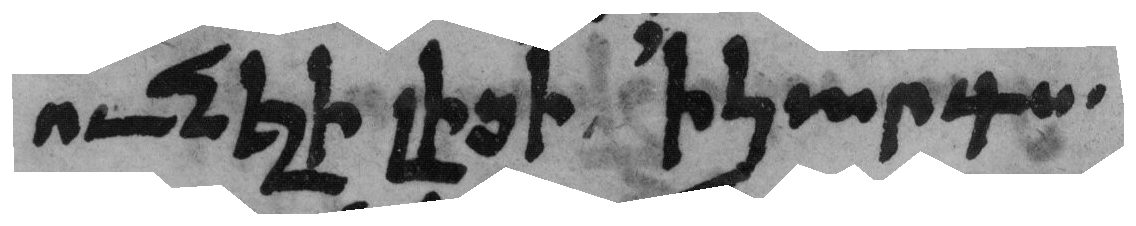

GT:   ունելի լիցի իկարգս․
PRED: ունելիլիի իկարգ
CER:  0.2105 (21.05%)
----------------------------------------------------------------------------------------------------
Sample 22 | ms_ucla_ms__0010__018


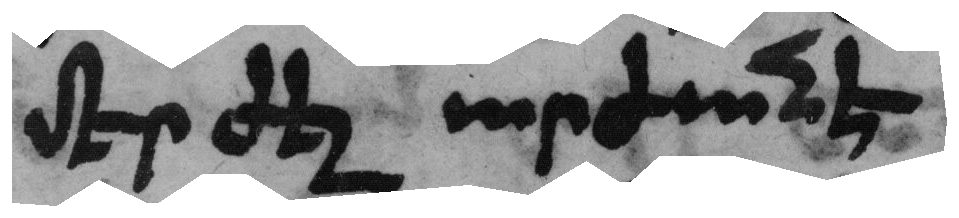

GT:   մերժել արժանէ
PRED: մերժել արժանէ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 23 | ms_ucla_ms__0010__020


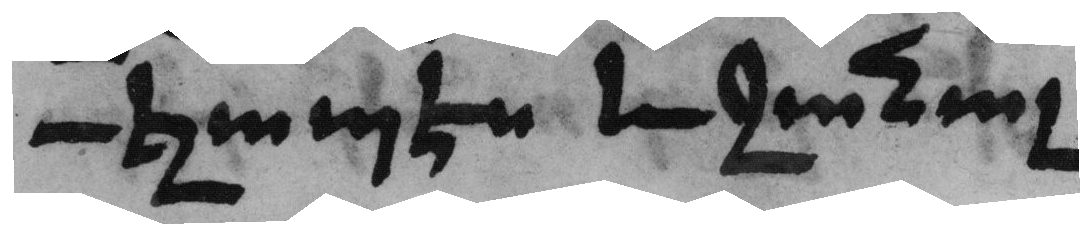

GT:   ւելապէս ևջանալ
PRED: ւեապէ ևջանալ
CER:  0.1429 (14.29%)
----------------------------------------------------------------------------------------------------
Sample 24 | ms_ucla_ms__0010__023


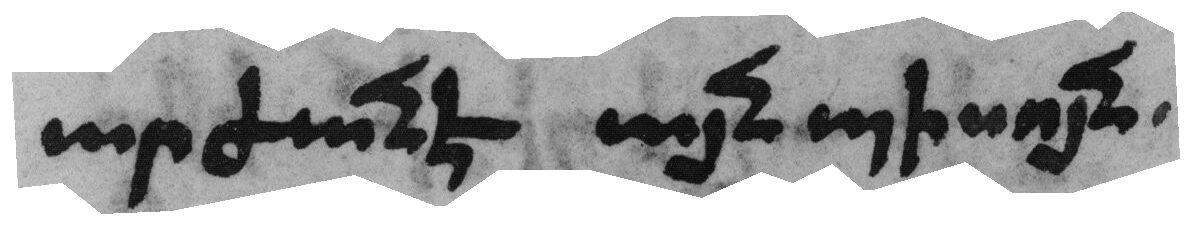

GT:   արժանէ այնպիսոյն․
PRED: արժանէ այնպիսոն․
CER:  0.0588 (5.88%)
----------------------------------------------------------------------------------------------------
Sample 25 | ms_ucla_ms__0010__031


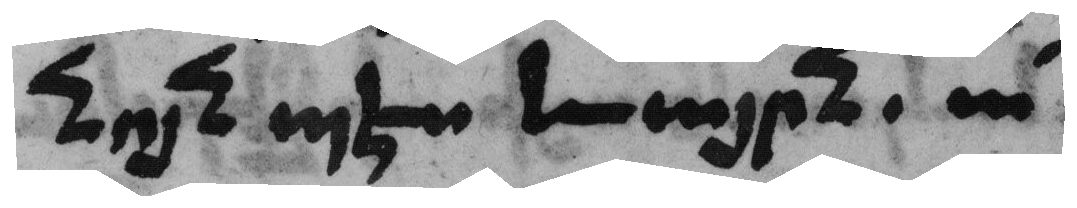

GT:   նոյն պէս ևայրն․ ա
PRED: նոյնպէ ևայրն․ ա
CER:  0.1176 (11.76%)
----------------------------------------------------------------------------------------------------
Sample 26 | ms_ucla_ms__0010__035


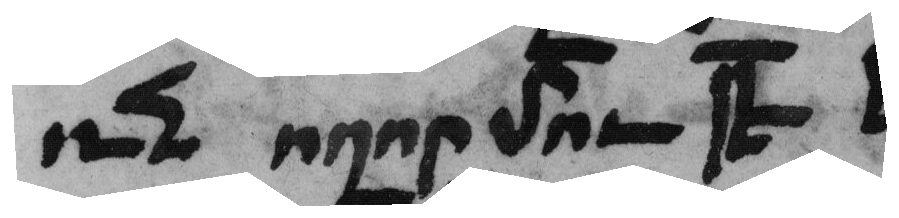

GT:   ռն ողորմութե և
PRED: ոն ողորմութե․
CER:  0.2143 (21.43%)
----------------------------------------------------------------------------------------------------
Sample 27 | ms_ucla_ms__0010__036


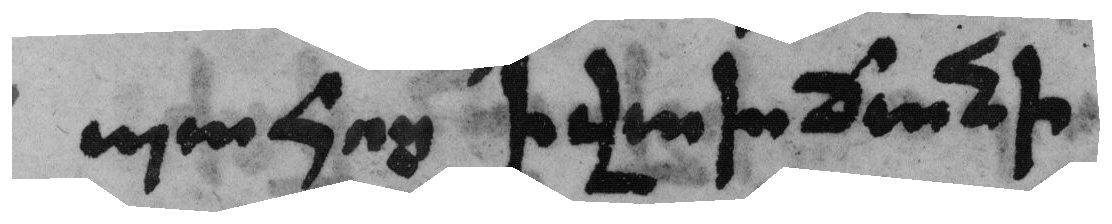

GT:   պահոց իվախճանի
PRED: պահո իվանճանի
CER:  0.1429 (14.29%)
----------------------------------------------------------------------------------------------------
Sample 28 | ms_ucla_ms__0010__040


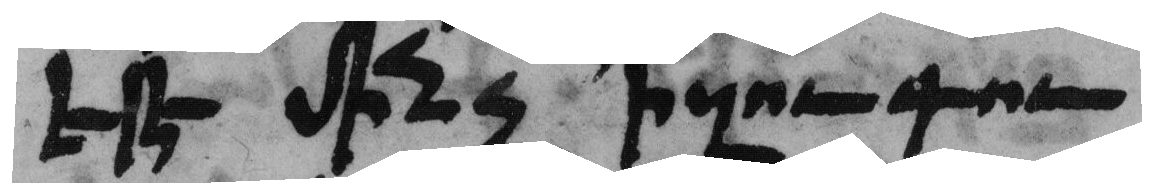

GT:   եթէ մինչ իզուգու
PRED: թթէ մինչ իզուգու
CER:  0.0625 (6.25%)
----------------------------------------------------------------------------------------------------
Sample 29 | ms_ucla_ms__0010__045


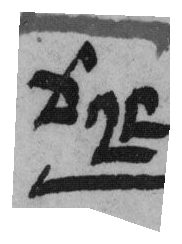

GT:   ճղը
PRED: ճղը
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 30 | ms_ucla_ms__0010__046


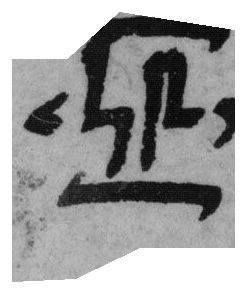

GT:   կթ
PRED: մե
CER:  1.0000 (100.00%)

Average CER over 30 random test samples: 0.1822 (18.22%)
Median CER over 30 random test samples:  0.0945 (9.45%)


In [ ]:
from statistics import mean, median

eval_images = sorted(test_images, key=lambda path: path.stem)
print(f"Evaluating all {len(eval_images)} test samples.\n")

rows = []
for idx, image_path in enumerate(eval_images, start=1):
    reference = ground_truth[image_path.name]
    prediction = predict_image(image_path)
    cer = character_error_rate(reference, prediction)
    rows.append(
        {
            "stem": image_path.stem,
            "image_path": image_path,
            "ground_truth": reference,
            "prediction": prediction,
            "cer": cer,
        }
    )
    print("-" * 100)
    print(f"Sample {idx:03d} | {image_path.stem}")
    display(IPyImage(filename=str(image_path)))
    print(f"GT:   {reference}")
    print(f"PRED: {prediction}")
    print(f"CER:  {cer:.4f} ({cer * 100:.2f}%)")

char_edits = sum(levenshtein_distance(row["ground_truth"], row["prediction"]) for row in rows)
char_refs = sum(len(row["ground_truth"]) for row in rows)
word_edits = sum(
    levenshtein_distance(row["ground_truth"].split(), row["prediction"].split()) for row in rows
)
word_refs = sum(len(row["ground_truth"].split()) for row in rows)
corpus_cer = char_edits / char_refs if char_refs else 0.0
corpus_wer = word_edits / word_refs if word_refs else 0.0
exact_match = sum(row["ground_truth"] == row["prediction"] for row in rows) / len(rows)
avg_cer = mean(row["cer"] for row in rows)
median_cer = median(row["cer"] for row in rows)

print("\n" + "=" * 100)
print(f"Test samples:     {len(rows)}")
print(f"Corpus CER:       {corpus_cer:.4f} ({corpus_cer * 100:.2f}%)  [{char_edits}/{char_refs} edits]")
print(f"Corpus WER:       {corpus_wer:.4f} ({corpus_wer * 100:.2f}%)  [{word_edits}/{word_refs} edits]")
print(f"Exact match:      {exact_match:.4f} ({exact_match * 100:.2f}%)")
print(f"Mean line CER:    {avg_cer:.4f} ({avg_cer * 100:.2f}%)")
print(f"Median line CER:  {median_cer:.4f} ({median_cer * 100:.2f}%)")


# Pretraining checkpoint: low confidence and length 42–57 errors

Uses `checkpoints/calamari/pretrained/on_armenian/lstm_layers_3/final/best.pt` (W&B run `calamari-pretraining-armenian-final`) on the **pretraining val** split — the same split that logged the length-bin CERs.

Sequence confidence is the mean greedy-CTC character softmax (blank and repeat frames dropped). Per-character confidence is that same softmax for each kept character.


In [ ]:
import torch.nn.functional as F
from collections import Counter, defaultdict

PRETRAIN_CKPT = (
    REPO
    / "checkpoints"
    / "calamari"
    / "pretrained"
    / "on_armenian"
    / "lstm_layers_3"
    / "final"
    / "best.pt"
)
PRETRAIN_DIR = REPO / "data" / "processed" / "armenian" / "pretraining"
PRETRAIN_IMAGES = PRETRAIN_DIR / "image"
PRETRAIN_GT = PRETRAIN_DIR / "gt_val.txt"

pretrain_gt = {}
for line in PRETRAIN_GT.read_text(encoding="utf-8").splitlines():
    if line:
        name, text = line.split("\t", 1)
        pretrain_gt[name] = text

pretrain_model, pretrain_meta = load_calamari_checkpoint(PRETRAIN_CKPT)
pretrain_codec = CharacterCodec(pretrain_meta.charset)
pretrain_model = pretrain_model.to(device).eval()


def decode_with_confidence(logits, length, codec):
    probs = F.softmax(logits[: int(length)], dim=-1)
    ids = probs.argmax(dim=-1)
    max_probs = probs.max(dim=-1).values
    chars, confs = [], []
    previous = -1
    for token_id, conf in zip(ids.tolist(), max_probs.tolist()):
        if token_id != 0 and token_id != previous:
            chars.append(codec.charset[token_id])
            confs.append(float(conf))
        previous = token_id
    text = "".join(chars)
    mean_conf = sum(confs) / len(confs) if confs else 0.0
    min_conf = min(confs) if confs else 0.0
    return text, mean_conf, min_conf, confs


def align_ops(ref: str, hyp: str):
    n, m = len(ref), len(hyp)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    bt = [[""] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        dp[i][0] = i
        bt[i][0] = "del"
    for j in range(1, m + 1):
        dp[0][j] = j
        bt[0][j] = "ins"
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j], bt[i][j] = min(
                (dp[i - 1][j] + 1, "del"),
                (dp[i][j - 1] + 1, "ins"),
                (dp[i - 1][j - 1] + cost, "eq" if cost == 0 else "sub"),
            )
    ops = []
    i, j = n, m
    while i > 0 or j > 0:
        op = bt[i][j]
        if op in {"eq", "sub"}:
            ops.append((op, ref[i - 1], hyp[j - 1]))
            i -= 1
            j -= 1
        elif op == "del":
            ops.append(("del", ref[i - 1], ""))
            i -= 1
        else:
            ops.append(("ins", "", hyp[j - 1]))
            j -= 1
    ops.reverse()
    return ops


def format_alignment(ops):
    parts = []
    for op, a, b in ops:
        if op == "eq":
            parts.append(a)
        elif op == "sub":
            parts.append(f"[{a}→{b}]")
        elif op == "del":
            parts.append(f"[-{a}]")
        else:
            parts.append(f"[+{b}]")
    return "".join(parts)


val_rows = []
with torch.no_grad():
    for name, ref in pretrain_gt.items():
        image = _load_image(PRETRAIN_IMAGES / name, pretrain_meta.line_height).to(device)
        output = pretrain_model(image, torch.tensor([image.shape[1]], device=device))
        pred, conf, min_conf, char_confs = decode_with_confidence(
            output["logits"][0], output["out_len"][0], pretrain_codec
        )
        edits = levenshtein_distance(ref, pred)
        val_rows.append(
            {
                "file": name,
                "ref": ref,
                "pred": pred,
                "ref_len": len(ref),
                "edits": edits,
                "cer": edits / len(ref) if ref else float(bool(pred)),
                "confidence": conf,
                "min_char_confidence": min_conf,
                "char_confs": char_confs,
            }
        )

edits_all = sum(row["edits"] for row in val_rows)
chars_all = sum(row["ref_len"] for row in val_rows)
print(f"Checkpoint: {PRETRAIN_CKPT}")
print(f"Val samples: {len(val_rows)}")
print(f"Overall CER: {edits_all / chars_all:.4f}")
print(f"Exact match: {sum(row['edits'] == 0 for row in val_rows) / len(val_rows):.4f}")


In [ ]:
print("Least confident val lines (mean greedy-character softmax)\n")
for row in sorted(val_rows, key=lambda item: item["confidence"])[:8]:
    print("-" * 100)
    print(
        f"{row['file']}  conf={row['confidence']:.3f}  "
        f"min_char={row['min_char_confidence']:.3f}  "
        f"CER={row['cer']:.3f}  len={row['ref_len']}"
    )
    display(IPyImage(filename=str(PRETRAIN_IMAGES / row["file"])))
    print(f"GT:   {row['ref']}")
    print(f"PRED: {row['pred']}")
    print(f"ALN:  {format_alignment(align_ops(row['ref'], row['pred']))}")


In [ ]:
char_conf_sum = defaultdict(float)
char_conf_n = Counter()
for row in val_rows:
    for char, conf in zip(row["pred"], row["char_confs"]):
        char_conf_sum[char] += conf
        char_conf_n[char] += 1

print("Lowest mean confidence by predicted character (n ≥ 10)")
ranked = sorted(
    (
        (char_conf_sum[char] / char_conf_n[char], char_conf_n[char], char)
        for char in char_conf_n
    )
)
for mean, n, char in ranked:
    if n >= 10:
        print(f"  {mean:.3f}  n={n:4d}  {char!r}")

print("\nAlso low but rarer (3 ≤ n < 10)")
for mean, n, char in ranked:
    if 3 <= n < 10:
        print(f"  {mean:.3f}  n={n:4d}  {char!r}")


In [ ]:
band = [row for row in val_rows if 42 <= row["ref_len"] <= 57]
band_edits = sum(row["edits"] for row in band)
band_chars = sum(row["ref_len"] for row in band)
print(
    f"Ref length 42–57: {len(band)} samples, "
    f"{band_edits} edits / {band_chars} chars, "
    f"CER={band_edits / band_chars:.4f}"
)
print(f"Share of all val edits: {band_edits}/{edits_all} = {band_edits / edits_all:.1%}")

subs, dels, ins, gt_wrong = Counter(), Counter(), Counter(), Counter()
for row in band:
    for op, a, b in align_ops(row["ref"], row["pred"]):
        if op == "sub":
            subs[(a, b)] += 1
            gt_wrong[a] += 1
        elif op == "del":
            dels[a] += 1
            gt_wrong[a] += 1
        elif op == "ins":
            ins[b] += 1

print("\nGT characters most often wrong in 42–57")
for char, n in gt_wrong.most_common(12):
    print(f"  {n:3d}  {char!r}")
print("\nTop substitutions (GT → PRED)")
for (a, b), n in subs.most_common(10):
    print(f"  {n:3d}  {a!r} → {b!r}")
print("\nTop deletions (missing from PRED)")
for char, n in dels.most_common(8):
    print(f"  {n:3d}  {char!r}")
print("\nTop insertions (extra in PRED)")
for char, n in ins.most_common(8):
    print(f"  {n:3d}  {char!r}")

print("\nWorst lines in this band")
for row in sorted(band, key=lambda item: (-item["edits"], -item["cer"]))[:8]:
    print("-" * 100)
    print(
        f"{row['file']}  edits={row['edits']}  CER={row['cer']:.3f}  "
        f"conf={row['confidence']:.3f}  len={row['ref_len']}"
    )
    display(IPyImage(filename=str(PRETRAIN_IMAGES / row["file"])))
    print(f"GT:   {row['ref']}")
    print(f"PRED: {row['pred']}")
    print(f"ALN:  {format_alignment(align_ops(row['ref'], row['pred']))}")



Worst examples


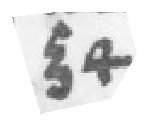

ms_p_172__0007__054 | CER=100.00%
GT:   ձգ
PRED: կ



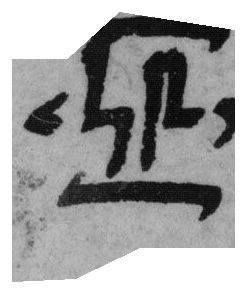

ms_ucla_ms__0010__046 | CER=100.00%
GT:   կթ
PRED: մե



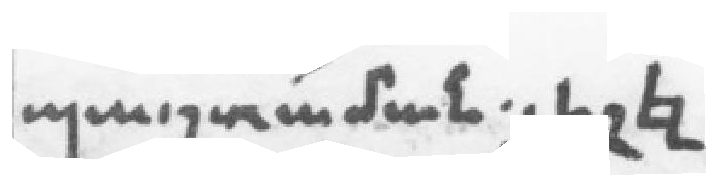

ms_p_172__0007__028 | CER=46.67%
GT:   պաշտաման․ յիշել
PRED: պատումանա ւել


Best examples


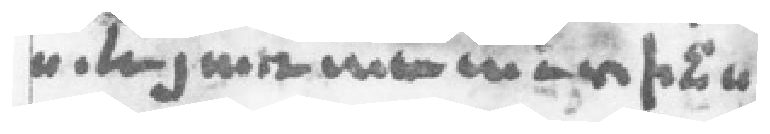

ms_p_172__0007__017 | CER=0.00%
GT:   ս․ ևյառաւաւտինս
PRED: ս․ ևյառաւաւտինս



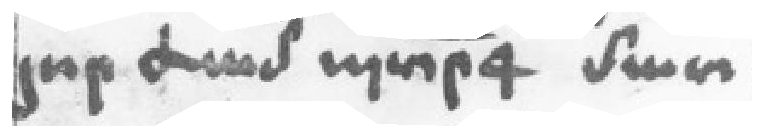

ms_p_172__0007__025 | CER=0.00%
GT:   յորժամ պտրգ մատ
PRED: յորժամ պտրգ մատ



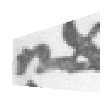

ms_p_172__0007__027 | CER=0.00%
GT:   ռճ
PRED: ռճ



In [ ]:
worst_rows = sorted(rows, key=lambda item: item["cer"], reverse=True)[:3]
best_rows = sorted(rows, key=lambda item: item["cer"])[:3]

for label, subset in (("Worst", worst_rows), ("Best", best_rows)):
    print(f"\n{label} examples")
    for row in subset:
        display(IPyImage(filename=str(row["image_path"])))
        print(f"{row['stem']} | CER={row['cer'] * 100:.2f}%")
        print(f"GT:   {row['ground_truth']}")
        print(f"PRED: {row['prediction']}")
        print()
